[nltk_data] Downloading package punkt_tab to /home/paulb/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/paulb/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Loads checkpoint by local backend from path: work_dirs/polyp_config/best_coco_bbox_mAP_epoch_2.pth


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


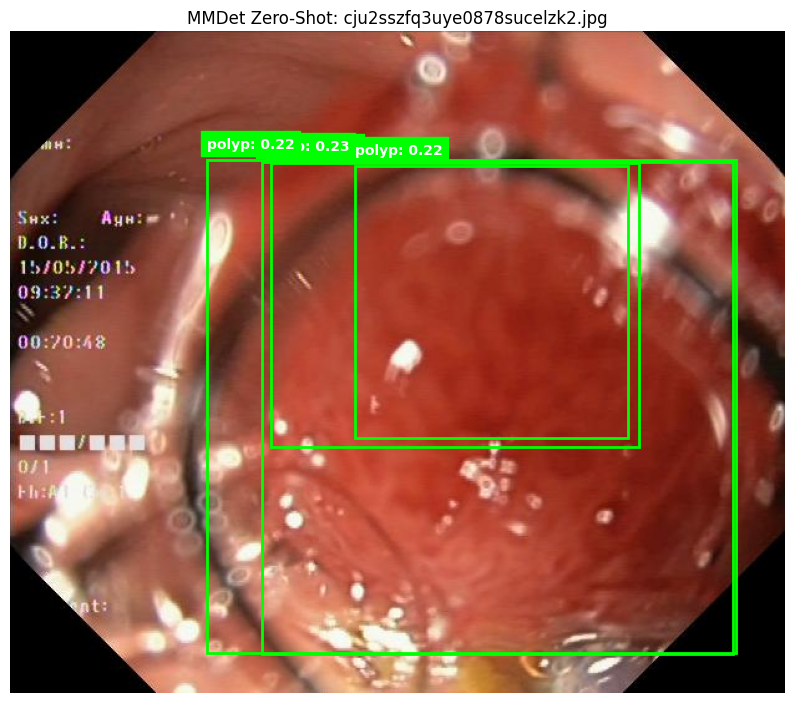

In [3]:
import torch
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
import mmcv
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random
import glob

import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# 1. Initialisation
# register_all_modules est crucial pour que MMDetection trouve GroundingDINO
register_all_modules()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Chemins vers les fichiers téléchargés via mim
config_file = 'work_dirs/polyp_config/polyp_config.py'
checkpoint_file = 'work_dirs/polyp_config/best_coco_bbox_mAP_epoch_2.pth'

# Chargement du modèle
model = init_detector(config_file, checkpoint_file, device=device)

def test_mmdet_grounding_dino(image_path, text_prompt="polyp"):
    # MMDetection 3.x attend souvent le point final pour Grounding DINO
    if not text_prompt.endswith('.'):
        text_prompt += '.'
    
    # Inférence
    # Pour Grounding DINO, on passe le texte via l'argument text_prompt
    result = inference_detector(model, image_path, text_prompt=text_prompt)
    
    # Extraction des résultats (format DetDataSample)
    pred_instances = result.pred_instances
    
    # Filtrage par seuil (threshold)
    # On garde les scores > 0.3
    scores = pred_instances.scores.cpu().numpy()
    bboxes = pred_instances.bboxes.cpu().numpy()
    labels = pred_instances.labels.cpu().numpy() # Note: DINO renvoie souvent le même label pour le texte
    
    mask = scores > 0.2
    valid_boxes = bboxes[mask]
    valid_scores = scores[mask]

    # Visualisation
    image = mmcv.imread(image_path)
    image = mmcv.rgb2bgr(image) # MMDetection travaille souvent en BGR en interne
    image = Image.fromarray(image)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)

    for score, box in zip(valid_scores, valid_boxes):
        # Format MMDetection : [xmin, ymin, xmax, ymax]
        rect = patches.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(box[0], box[1]-10, f"polyp: {score:.2f}", color='white', 
                backgroundcolor='lime', fontsize=10, fontweight='bold')

    plt.axis('off')
    plt.title(f"MMDet Zero-Shot: {os.path.basename(image_path)}")
    plt.show()

# Test aléatoire
# img_dir = "data/Kvasir-SEG/images"
# image_paths = glob.glob(os.path.join(img_dir, "*.jpg"))
# if image_paths:
#     test_mmdet_grounding_dino(random.choice(image_paths))

test_mmdet_grounding_dino("data/Kvasir-SEG/images/cju2sszfq3uye0878sucelzk2.jpg")